# Week 1 · From Raw Financial Data to First Insights
### FinTech & AI Engineering — MSc Banking & Finance

---

## 🧭 Where this course is going (read this first)

Over the next 11 weeks you are going to build, step by step, your own **AI-native financial analytics product**. Its engine will be a small pipeline of AI agents (think about this as being a small Startup) — a *Data Agent*, an *Analyst Agent*, a *Risk Agent* — and your role will be that of the **orchestrator**: the person who specifies what the agents do, verifies their output, and takes responsibility for the result. This is exactly the role emerging across banks, asset managers, and FinTechs today.

There is one iron rule in this course:

> **Human first, agent second.** Before you are allowed to delegate a task to an AI agent, you must be able to do it yourself and *verify* it with theory. An agent you cannot audit is a black box, and black boxes have no place in finance.

**This week you do everything by hand.** You will download real market data, load it into Python, and extract its first secrets: returns, volatility, fat tails, drawdowns, correlations. In later weeks, an agent will do this for you in seconds — and you will be the one who can tell whether it did it *correctly*.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Acquire real financial time-series data (equities, FX, crypto) and load it from Excel/CSV files into Python.
2. Explain what every library in our toolkit does and why we need it.
3. Transform prices into **returns** and explain why finance works with returns, not prices.
4. Produce and *interpret* six fundamental charts every analyst uses on day one with a new dataset.
5. Compute and interpret a professional summary-statistics table (annualized return, volatility, Sharpe ratio, skewness, kurtosis, maximum drawdown, VaR).
6. State the **stylized facts** of financial returns — the empirical regularities that every model in this course must respect.

## 🗺️ How to use this notebook

Run cells top to bottom (`Shift+Enter`). Markdown cells carry the theory; code cells carry the practice, with every step commented. Two sections at the end (SQL, GitHub) are **optional** — recommended, but not graded.


---
# 1 · The toolkit — what each library does and why we need it

Python by itself knows almost nothing about data. Its power comes from **libraries**: collections of pre-built, battle-tested code that we import. Think of Python as the workshop and libraries as the machine tools. Ours for this week:

| Library | What it is | Why we need it here |
|---|---|---|
| **`pandas`** | The de-facto standard for tabular data in Python. Its core object, the `DataFrame`, is essentially a programmable Excel sheet: rows, columns, labels. | Loading Excel/CSV files, aligning dates, computing returns, rolling statistics. ~90% of a data analyst's day lives here. |
| **`numpy`** | The numerical engine underneath pandas. Provides fast arrays and mathematical functions (`log`, `sqrt`, random numbers). | Log returns, annualization ($\sqrt{252}$), and our synthetic-data fallback. |
| **`matplotlib`** | The foundational plotting library. Nearly every Python chart you have ever seen was drawn by it, directly or indirectly. | All six of our exploratory charts. |
| **`openpyxl`** | A reader/writer for `.xlsx` files. pandas calls it behind the scenes whenever you use `read_excel`. | Lets us load the Excel files you download. |
| **`pathlib`** | Part of Python's standard library — object-oriented file paths. | Checking which data files exist, in a way that works identically on Windows, macOS, and Linux. |
| **`sqlite3`** | A complete SQL database engine that ships *inside* Python — no installation, no server. | The optional SQL appendix. |

**Installation** (one-time, in a terminal or a notebook cell prefixed with `!`):

```bash
pip install pandas numpy matplotlib openpyxl
```

The cell below imports everything and prints the versions — your first sanity check. If it runs without errors, your environment is ready.


In [136]:
# ============================================================
# Cell 1 — Imports and environment check
# ============================================================
# The `import X as y` pattern gives a library a short alias.
# These aliases (pd, np, plt) are universal conventions — every
# tutorial, colleague, and AI assistant will use the same ones.

import sys                      # access to the Python interpreter itself (version info)
from pathlib import Path        # object-oriented, cross-platform file paths

import numpy as np              # numerical arrays and math functions
import pandas as pd             # DataFrames: labeled, tabular data
import matplotlib.pyplot as plt # plotting

# Display settings: make pandas output readable in class
pd.set_option("display.max_columns", 12)   # show up to 12 columns
pd.set_option("display.width", 120)        # wider console output
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")  # 4 decimals, thousands sep

# Reproducibility: any randomness in this notebook uses this seed,
# so everyone in class sees exactly the same numbers.
RNG = np.random.default_rng(seed=42)

print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("✅ Environment ready.")


Python  : 3.14.5
pandas  : 3.0.3
numpy   : 2.4.6
✅ Environment ready.


---
# 2 · Getting the data — three assets, three asset classes

We deliberately pick one asset from each of the three worlds this course covers:

| Asset | Ticker | Asset class | Why it matters |
|---|---|---|---|
| **S&P 500 ETF** | SPY | Equities (TradFi) | The world's benchmark equity index — "the market". |
| **EUR/USD** | EURUSD | Foreign exchange | The most traded currency pair on Earth; the euro's pulse. |
| **Bitcoin** | BTCUSD | Crypto | The reference cryptoasset; a completely different statistical animal, as you are about to see. |

## 📥 Your task (before or during class): download the files

**Option A — Stooq (fastest, no registration).** Each link downloads a full daily-history CSV instantly:

- SPY: `https://stooq.com/q/d/l/?s=spy.us&i=d`
- EUR/USD: `https://stooq.com/q/d/l/?s=eurusd&i=d`
- Bitcoin: `https://stooq.com/q/d/l/?s=btcusd&i=d`

**Option B — Yahoo Finance.** Search the ticker → *Historical Data* → set period to *Max* → *Download*.

Then:

1. Create a folder called **`data`** in the same directory as this notebook.
2. Save (or move) the files there with these exact names: **`spy.csv`**, **`eurusd.csv`**, **`btc.csv`**.
3. *Optional but encouraged:* open one file in Excel, look at it, and use *Save As → Excel Workbook* to produce `spy.xlsx` etc. Our loader accepts **both** `.csv` and `.xlsx` — a small lesson in writing flexible code.

## 🔎 What is inside these files? The anatomy of OHLCV

Each row is one trading day with five numbers, the market-data industry standard:

- **Open** — first traded price of the day
- **High / Low** — the day's extremes (the intraday battlefield)
- **Close** — last traded price; the number "the market closed at" on the news
- **Volume** — how many units changed hands (activity / liquidity)

This week we work almost exclusively with the **Close** — the daily heartbeat of an asset.


In [137]:
#==========================================
# download directly form Yahoo Finance
#==========================================
import yfinance as yf
from pathlib import Path

Path("data").mkdir(exist_ok=True)

# {file stem: Yahoo ticker} — note Yahoo's special symbols for FX and crypto
TICKERS = {"Euro Treasury Bills & Bonds": "IEGE.AS", "ETHEREUM": "ETH-USD", "ATHEX": "AETF.AT"}

for stem, ticker in TICKERS.items():
    data = yf.download(
        ticker,
        start="2017-05-27",          # Eth inception; others start when their history begins
        auto_adjust=True,            # Close adjusted for dividends/splits (what you want)
        multi_level_index=False,     # flat columns -> clean CSV header
    )
    data.to_csv(f"data/{stem}.csv")  # f-string: filename follows the loop variable
    print(f"✅ {stem}: {len(data):,} rows saved")

[*********************100%***********************]  1 of 1 completed


✅ Euro Treasury Bills & Bonds: 2,377 rows saved


[*********************100%***********************]  1 of 1 completed


✅ ETHEREUM: 3,228 rows saved


[*********************100%***********************]  1 of 1 completed

✅ ATHEX: 2,306 rows saved


In [138]:
# ============================================================
# Cell 2 — Configuration: where the data lives
# ============================================================
# Keeping configuration in ONE place at the top of a project is a
# professional habit: change it here, and everything downstream adapts.

DATA_DIR = Path("data")   # the folder next to this notebook

# For each asset: the file stem we expect, and a human-readable label.
ASSETS = {
    "IEGE.AS":    {"stem": "Euro Treasury Bills & Bonds",    "label": "Euro Government Bonds"},
    "ETH-USD": {"stem": "ETHEREUM", "label": "ETH CRYPTO"},
    "AETF.AT":    {"stem": "ATHEX",    "label": "ATHEX"},
}

DATA_DIR.mkdir(exist_ok=True)   # create the folder if it doesn't exist yet
print(f"Looking for data in: {DATA_DIR.resolve()}")


Looking for data in: C:\Users\gkomp\Desktop\Large Data Class\Data


## 2.1 · The loader — defensive, flexible, honest

We now write a small **function**. Why a function and not just five loose lines of code? Three reasons that will follow you all course:

1. **Reuse** — we load three files; the logic is written once.
2. **Testability** — a function with clear inputs/outputs can be checked (and, later, handed to an agent as a *tool*).
3. **Readability** — `load_price_file("spy")` reads like English.

The loader is *defensive*: it tries `.csv` first, then `.xlsx`, standardizes column names to lowercase (data vendors are wildly inconsistent: `Date`, `DATE`, `date`...), parses the date column into real datetime objects, and returns `None` — honestly, without crashing — if the file simply is not there.


In [139]:
# ============================================================
# Cell 3 — A defensive file loader
# ============================================================

def load_price_file(stem: str, data_dir: Path = DATA_DIR) -> pd.DataFrame | None:
    '''Load a daily OHLCV file named <stem>.csv or <stem>.xlsx.

    Returns a DataFrame indexed by date with lowercase columns,
    or None if no file is found.
    '''
    for ext, reader in ((".csv", pd.read_csv), (".xlsx", pd.read_excel)):
        path = data_dir / f"{stem}{ext}"
        if path.exists():
            df = reader(path)

            # --- Standardize column names: 'Date' -> 'date', 'Close' -> 'close'
            df.columns = [c.strip().lower() for c in df.columns]

            # --- Parse dates: text like "2024-03-15" becomes a real datetime.
            # Without this, "sorting by date" would sort alphabetically!
            df["date"] = pd.to_datetime(df["date"])

            # --- Time series 101: the date becomes the index (row label),
            # and rows are sorted chronologically.
            df = df.set_index("date").sort_index()

            print(f"✅ {path.name:<14} {len(df):>6,} rows   "
                  f"{df.index[0].date()} → {df.index[-1].date()}")
            return df

    print(f"⚠️  No file found for '{stem}' (looked for .csv / .xlsx)")
    return None


# Try to load all three assets into a dictionary: {name: DataFrame}
raw = {name: load_price_file(cfg["stem"]) for name, cfg in ASSETS.items()}


✅ Euro Treasury Bills & Bonds.csv  2,377 rows   2017-05-29 → 2026-09-10
✅ ETHEREUM.csv    3,228 rows   2017-11-09 → 2026-09-10
✅ ATHEX.csv       2,306 rows   2017-05-29 → 2026-09-10


## 2.2 · The safety net — synthetic data via Geometric Brownian Motion

What if a file is missing, a link is down, or the classroom wifi dies mid-demo? A professional pipeline **degrades gracefully**. Our fallback *generates* realistic fake prices using **Geometric Brownian Motion (GBM)** — the "hello world" of financial modeling and the engine inside the Black–Scholes formula.

The idea in one line: each day, the price changes by a small expected drift plus a random shock proportional to the price itself,

$$S_{t+1} = S_t \, \exp\!\Big[\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma\sqrt{\Delta t}\; Z_t\Big], \qquad Z_t \sim \mathcal{N}(0,1)$$

where $\mu$ is the annual drift (expected return) and $\sigma$ the annual volatility. Prices generated this way can never go negative and their *log returns are perfectly normal*.

**Remember that last property.** At the end of this notebook we will discover that *real* returns are decidedly **not** normal — which is exactly why GBM is a starting point, not the truth. Using the wrong-but-useful model as our safety net is itself a lesson.


In [140]:
# ============================================================
# Cell 4 — GBM generator + fill in any missing asset
# ============================================================

def generate_gbm(mu: float, sigma: float, s0: float,
                 start: str = "2018-01-01", end: str = "2025-12-31",
                 calendar: str = "B") -> pd.DataFrame:
    '''Simulate daily closing prices under Geometric Brownian Motion.

    mu, sigma : ANNUAL drift and volatility (e.g. 0.08 and 0.18)
    s0        : starting price
    calendar  : 'B' = business days (stocks/FX), 'D' = every day (crypto)
    '''
    dates = pd.date_range(start, end, freq=calendar)
    dt = 1 / 252                                   # one trading day in years
    # One standard-normal shock per day:
    z = RNG.standard_normal(len(dates))
    # Daily log returns under GBM (the formula from the markdown above):
    log_ret = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    # exp(cumulative sum of log returns) turns log returns back into a price path:
    prices = s0 * np.exp(np.cumsum(log_ret))
    return pd.DataFrame({"close": prices}, index=dates)


# Realistic annual parameters per asset class (rough historical orders of magnitude):
GBM_PARAMS = {
    "SPY":    dict(mu=0.09, sigma=0.18, s0=300.0, calendar="B"),  # equities
    "EURUSD": dict(mu=0.00, sigma=0.08, s0=1.15,  calendar="B"),  # FX: low vol, ~no drift
    "BTC":    dict(mu=0.30, sigma=0.70, s0=8000., calendar="D"),  # crypto: high vol, trades 24/7
}

for name in ASSETS:
    if raw[name] is None:
        raw[name] = generate_gbm(**GBM_PARAMS[name])
        print(f"🧪 {name}: using SYNTHETIC GBM data "
              f"(μ={GBM_PARAMS[name]['mu']:.0%}, σ={GBM_PARAMS[name]['sigma']:.0%})")
    else:
        print(f"📈 {name}: using REAL downloaded data")


📈 IEGE.AS: using REAL downloaded data
📈 ETH-USD: using REAL downloaded data
📈 AETF.AT: using REAL downloaded data


---
# 3 · First contact — interrogating an unknown dataset

You never trust a dataset you have not interrogated. Four commands form the analyst's opening ritual, each answering a different question:

| Command | Question it answers |
|---|---|
| `df.head()` / `df.tail()` | *What does the data physically look like — first and last rows?* Catches wrong delimiters, weird headers, stale end dates. |
| `df.info()` | *What columns exist, of what type, with how many non-missing values?* Catches numbers stored as text — a silent classic. |
| `df.describe()` | *What are the basic statistics — mean, std, min, max, quartiles?* Catches impossible values (a negative price, a close of 0). |
| `df.isna().sum()` | *How much is missing, and where?* |

Run the ritual on SPY:


In [141]:
# ============================================================
# Cell 5 — The inspection ritual
# ============================================================
ATHEX = raw["AETF.AT"]

print("── head() — the first 3 rows ──────────────────────────")
print(ATHEX.head(3))

print("\n── tail() — the last 3 rows (is the data fresh?) ─────")
print(ATHEX.tail(3))

print("\n── info() — column types and missing counts ──────────")
ATHEX.info()

print("\n── describe() — statistics of the close ──────────────")
print(ATHEX["close"].describe())

print("\n── missing values per column ──────────────────────────")
print(ATHEX.isna().sum())


── head() — the first 3 rows ──────────────────────────
             close    high     low    open  volume
date                                              
2017-05-29 19.3546 19.3546 19.3546 19.3546       0
2017-05-30 19.2898 19.2898 19.2898 19.2898    4257
2017-05-31 19.2898 19.2898 19.2898 19.2898       0

── tail() — the last 3 rows (is the data fresh?) ─────
             close    high     low    open  volume
date                                              
2026-09-08 69.8200 70.0700 69.3100 69.7000    2398
2026-09-09 69.5600 69.8200 68.8800 69.8200   13136
2026-09-10 69.4200 69.9300 69.2200 69.7200    1144

── info() — column types and missing counts ──────────
<class 'pandas.DataFrame'>
DatetimeIndex: 2306 entries, 2017-05-29 to 2026-09-10
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   2306 non-null   float64
 1   high    2306 non-null   float64
 2   low     2306 non-null   float64
 3   open    2306 non-nu

## 3.1 · Aligning three assets on one calendar

Our three assets live on **different calendars**: SPY and EUR/USD trade on business days; Bitcoin never sleeps and trades weekends too. To compare them we must put their closes side by side in one table, aligned by date.

`pd.concat(..., axis=1)` does exactly this: it matches rows **by index label** (the date). Where an asset has no observation for a date (SPY on a Saturday), pandas honestly inserts a `NaN` — *Not a Number*, the universal marker for "missing".

Our policy this week is the simplest defensible one: keep only dates where **all three** assets traded (`dropna()`). Week 2 is entirely devoted to smarter data hygiene — forward-filling, calendars, timezone traps.


In [142]:
# ============================================================
# Cell 6 — One master table of closing prices
# ============================================================
prices = pd.concat(
    {name: df["close"] for name, df in raw.items()},  # {column name: series}
    axis=1                                            # align by date index
)

print("Shape before alignment:", prices.shape)
print("Missing values per asset (different trading calendars!):")
print(prices.isna().sum(), "\n")

# Keep only dates where ALL assets have a price (inner-join logic):
prices = prices.dropna()

# Focus the analysis window (adjust freely — the code adapts):
prices = prices.loc["2017-05-27":]

print("Shape after alignment:", prices.shape)
prices.tail()


Shape before alignment: (3346, 3)
Missing values per asset (different trading calendars!):
IEGE.AS     969
ETH-USD     118
AETF.AT    1040
dtype: int64 

Shape after alignment: (2190, 3)


C:\Users\gkomp\AppData\Local\Temp\ipykernel_23844\175414808.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  prices = pd.concat(


,IEGE.AS,ETH-USD,AETF.AT
date,,,
2026-09-03,98.7500,"2,508.0208",69.2500
2026-09-04,98.7600,"2,456.0781",69.5300
2026-09-07,98.7500,"2,490.9580",69.7000
2026-09-08,98.7700,"2,484.9414",69.8200
2026-09-10,98.7000,"2,461.6899",69.4200


---
# 4 · From prices to returns — the most important transformation in finance

**Why not just analyze prices?** Two deep reasons:

1. **Comparability.** "SPY moved $\$4$" and "Bitcoin moved $4" are incomparable statements; "+0.8% vs +0.005%" are directly comparable. Returns are scale-free.
2. **Statistical stability.** Prices wander without a fixed average (they are *non-stationary* — Week 3 makes this precise with the ADF test). Returns hover around a stable mean with roughly stable behavior. Nearly every statistical tool you will ever use assumes this stability — feed it prices and it will confidently lie to you.

Two definitions, both used daily in practice:

- **Simple return:** $\;R_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}\;$ — the percentage change. Aggregates cleanly **across assets** (a portfolio's return is the weighted average of simple returns).
- **Log return:** $\;r_t = \ln\!\dfrac{P_t}{P_{t-1}}\;$ — aggregates cleanly **across time** (a month's log return is the *sum* of daily log returns).

For daily moves the two are nearly identical ($\ln(1+x)\approx x$ for small $x$); the distinction bites for big moves — and crypto delivers big moves. We compute both and use **log returns** for the statistics.


In [143]:
# ============================================================
# Cell 7 — Computing returns
# ============================================================
# .pct_change(): (P_t - P_{t-1}) / P_{t-1}, i.e. the simple return.
simple_ret = prices.pct_change()

# Log return: ln(P_t / P_{t-1}). prices.shift(1) is yesterday's price.
log_ret = np.log(prices / prices.shift(1))

# The first row has no "yesterday" -> NaN by construction. Drop it:
simple_ret, log_ret = simple_ret.dropna(), log_ret.dropna()

print("Daily log returns — first look:")
print(log_ret.head(3))

print("\nSanity check — daily means (tiny numbers are normal!):")
print(log_ret.mean())

print("\nHow close are simple and log returns on a typical day?")
print((simple_ret - log_ret).abs().mean(), "\n(≈0: the approximation holds for daily data)")


Daily log returns — first look:
            IEGE.AS  ETH-USD  AETF.AT
date                                 
2017-11-10   0.0000  -0.0698   0.0000
2017-11-13   0.0001   0.0567  -0.0354
2017-11-14   0.0001   0.0639   0.0113

Sanity check — daily means (tiny numbers are normal!):
IEGE.AS   0.0000
ETH-USD   0.0009
AETF.AT   0.0006
dtype: float64

How close are simple and log returns on a typical day?
IEGE.AS   0.0000
ETH-USD   0.0014
AETF.AT   0.0001
dtype: float64 
(≈0: the approximation holds for daily data)


---
# 5 · Informative graphs — six charts that reveal a dataset's character

A chart is not decoration; **each chart answers one question**. Here is the professional's opening sequence — memorize the *questions*, not just the code:

| # | Chart | Question |
|---|---|---|
| 1 | Growth of \$100 | *If I had invested \$100 in each, what happened?* |
| 2 | Daily returns strip | *When is each asset calm, and when does it panic?* |
| 3 | Histogram vs normal curve | *Are extreme days rarer or more common than a normal distribution says?* |
| 4 | Rolling volatility | *How does risk itself move over time?* |
| 5 | Drawdown curve | *How deep was the pain from the last peak?* |
| 6 | Correlation heatmap | *Do these assets move together — is there diversification here?* |


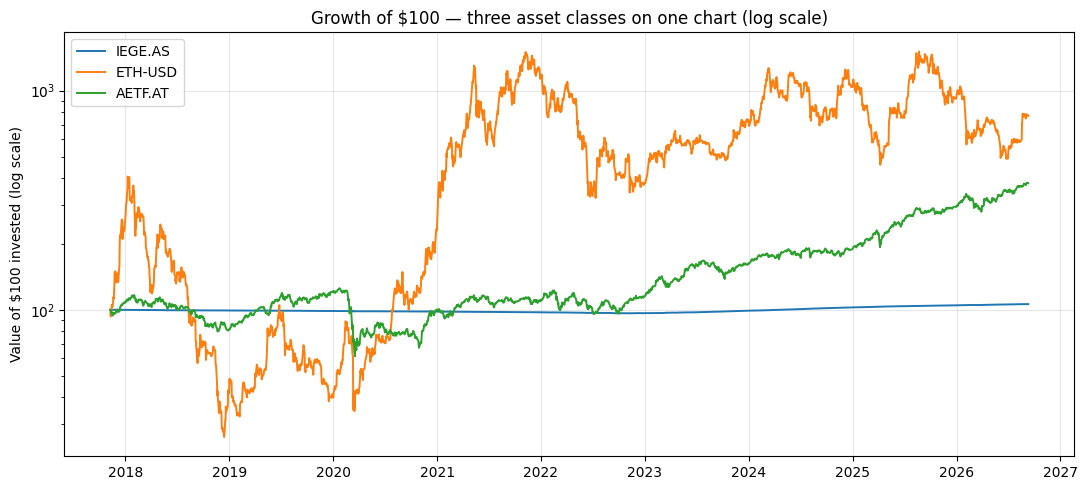

In [144]:
# ============================================================
# Chart 1 — Growth of $100 (normalized prices)
# ============================================================
# Trick: divide each series by its own first value, times 100.
# Now all assets start at 100 and become directly comparable.
growth = 100 * prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
for col in growth.columns:
    ax.plot(growth.index, growth[col], label=col, linewidth=1.4)
ax.set_yscale("log")   # log scale: equal vertical steps = equal % gains.
                       # Essential when one asset (BTC) grows 10x more than another.
ax.set_title("Growth of $100 — three asset classes on one chart (log scale)")
ax.set_ylabel("Value of $100 invested (log scale)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# READ THE CHART: which asset would have made you richest? At what cost?
# The next charts quantify that "cost" — volatility and drawdowns.


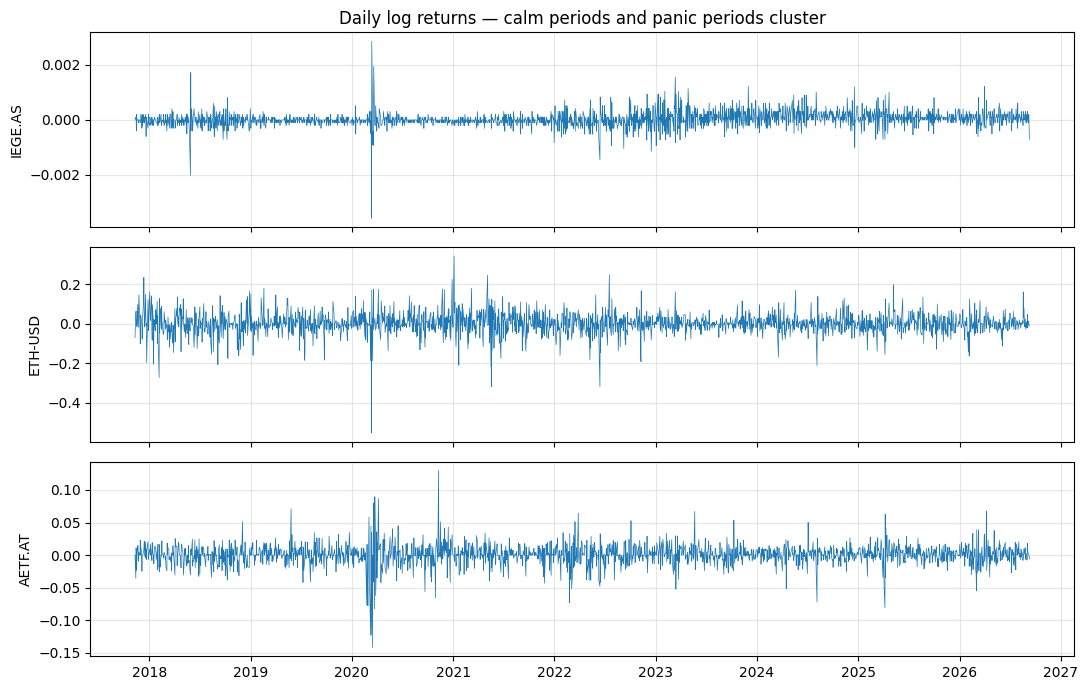

In [145]:
# ============================================================
# Chart 2 — Daily returns strip: volatility clustering, visible
# ============================================================
fig, axes = plt.subplots(len(log_ret.columns), 1, figsize=(11, 7), sharex=True)
for ax, col in zip(axes, log_ret.columns):
    ax.plot(log_ret.index, log_ret[col], linewidth=0.5)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)
axes[0].set_title("Daily log returns — calm periods and panic periods cluster")
plt.tight_layout(); plt.show()

# READ THE CHART: turbulence is not spread evenly — big moves bunch together
# (look for the COVID crash region if your data covers 2020). This is
# VOLATILITY CLUSTERING, stylized fact #2, and the reason GARCH models exist.


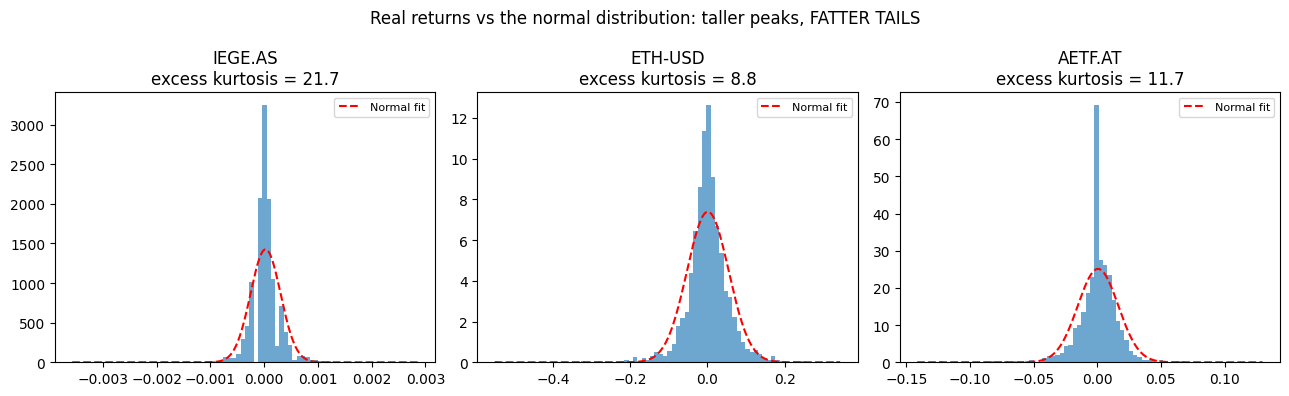

In [146]:
# ============================================================
# Chart 3 — Histogram vs the normal curve: meet the fat tails
# ============================================================
from scipy import stats as sps   # scipy.stats: probability distributions & tests
# (If scipy is missing: pip install scipy — it rides along with the ML stack anyway.)

fig, axes = plt.subplots(1, len(log_ret.columns), figsize=(13, 4))
for ax, col in zip(axes, log_ret.columns):
    r = log_ret[col]
    ax.hist(r, bins=80, density=True, alpha=0.65)          # empirical distribution
    x = np.linspace(r.min(), r.max(), 400)
    ax.plot(x, sps.norm.pdf(x, r.mean(), r.std()),         # normal with same mean/std
            "r--", linewidth=1.5, label="Normal fit")
    ax.set_title(f"{col}\nexcess kurtosis = {r.kurtosis():.1f}")
    ax.legend(fontsize=8)
plt.suptitle("Real returns vs the normal distribution: taller peaks, FATTER TAILS")
plt.tight_layout(); plt.show()

# READ THE CHART: the red dashed line is what GBM/Black-Scholes assumes.
# Reality has more boring days (tall center) AND more catastrophic/euphoric
# days (fat tails) than the normal curve allows. Excess kurtosis ≈ 0 for a
# normal; equities typically show 5-15, crypto often more.


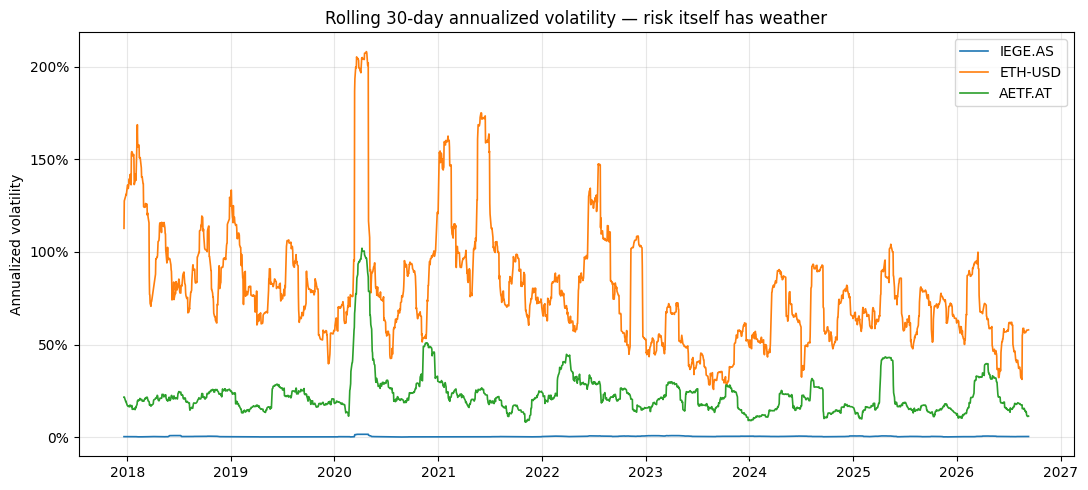

In [147]:
# ============================================================
# Chart 4 — Rolling 30-day volatility: risk is a moving target
# ============================================================
# .rolling(30).std() = standard deviation over a sliding 30-day window.
# Multiplying by sqrt(252) ANNUALIZES it (252 trading days/year):
# daily std × √252 → the "vol" numbers professionals quote (e.g. "18% vol").
roll_vol = log_ret.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 5))
for col in roll_vol.columns:
    ax.plot(roll_vol.index, roll_vol[col], label=col, linewidth=1.2)
ax.set_title("Rolling 30-day annualized volatility — risk itself has weather")
ax.set_ylabel("Annualized volatility")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# READ THE CHART: volatility spikes in crises and decays slowly afterwards.
# A single "the volatility of SPY is X%" is therefore always a simplification.


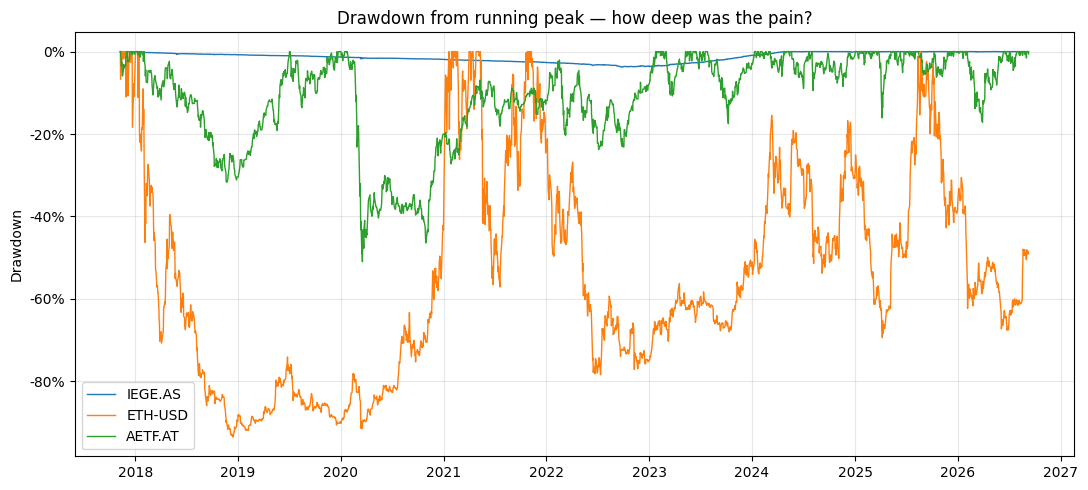

Maximum drawdown per asset (the worst peak-to-trough loss):
IEGE.AS     -3.7%
ETH-USD    -93.5%
AETF.AT    -51.0%
dtype: str


In [148]:
# ============================================================
# Chart 5 — Drawdown: the investor's pain chart
# ============================================================
# Drawdown at time t = how far the price sits below its highest point SO FAR:
#   DD_t = P_t / max(P_1..P_t) - 1        (0 at new highs, negative otherwise)
# .cummax() computes that running maximum in one call.
drawdown = prices / prices.cummax() - 1

fig, ax = plt.subplots(figsize=(11, 5))
for col in drawdown.columns:
    ax.plot(drawdown.index, drawdown[col], label=col, linewidth=1.0)
ax.set_title("Drawdown from running peak — how deep was the pain?")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Maximum drawdown per asset (the worst peak-to-trough loss):")
print(drawdown.min().apply(lambda v: f"{v:.1%}"))

# READ THE CHART: BTC's maximum drawdowns of -70%+ are the price of its
# spectacular growth chart #1 showed. Return and risk are inseparable twins.


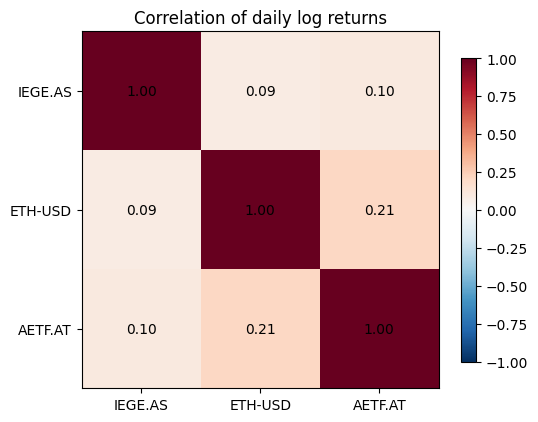

In [149]:
# ============================================================
# Chart 6 — Correlation heatmap: do they move together?
# ============================================================
# Correlation of DAILY RETURNS (never of prices! Two upward-drifting prices
# look "correlated" even if their daily moves are unrelated).
corr = log_ret.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")   # red=+1, blue=-1
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):                              # print the numbers on top
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation of daily log returns")
plt.tight_layout(); plt.show()

# READ THE CHART: low correlations = diversification potential — the only
# free lunch in finance (Markowitz). Note: correlations are not constant;
# in crises they tend to rise exactly when you need diversification most.


---
# 6 · The professional summary table — one row per asset, everything that matters

Every fund factsheet, risk report, and pitch deck contains a version of this table. Definitions (with $r_t$ the daily log returns, $N=252$ trading days/year):

| Statistic | Formula / idea | Interpretation |
|---|---|---|
| **Annualized return** | $\bar r \times 252$ | Average yearly log growth rate. |
| **Annualized volatility** | $s_r \times \sqrt{252}$ | Typical size of a year's fluctuations. The $\sqrt{252}$ comes from variances adding over time for (roughly) independent returns. |
| **Sharpe ratio** | $\dfrac{\text{ann. return} - r_f}{\text{ann. vol}}$ | Reward per unit of risk. Rule of thumb: <0.5 weak · ~1 good · >2 suspicious (check the data!). We take $r_f \approx 2\%$. |
| **Skewness** | 3rd standardized moment | Asymmetry. Negative = crashes bigger than rallies (typical for equities). |
| **Excess kurtosis** | 4th standardized moment − 3 | Fat tails. 0 for a normal distribution; markets are far above 0. |
| **Max drawdown** | $\min_t (P_t/\max_{s\le t}P_s - 1)$ | Worst historical peak-to-trough loss — the pain an investor actually felt. |
| **VaR 95% (daily, historical)** | 5th percentile of daily returns | "On the worst 1 day in 20, you lose at least this much." The workhorse of bank risk reporting. |


In [150]:
# ============================================================
# Cell 8 — Build the summary table
# ============================================================
RF = 0.02   # assumed risk-free rate (annual), for the Sharpe ratio

def summarize(returns: pd.Series, dd: pd.Series) -> dict:
    '''All key statistics for one asset, from daily log returns + drawdowns.'''
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    return {
        "Ann. return":     f"{ann_ret:.1%}",
        "Ann. volatility": f"{ann_vol:.1%}",
        "Sharpe (rf=2%)":  f"{(ann_ret - RF) / ann_vol:.2f}",
        "Skewness":        f"{returns.skew():.2f}",
        "Excess kurtosis": f"{returns.kurtosis():.2f}",   # pandas already subtracts 3
        "Max drawdown":    f"{dd.min():.1%}",
        "VaR 95% (daily)": f"{returns.quantile(0.05):.2%}",
    }

summary = pd.DataFrame(
    {col: summarize(log_ret[col], drawdown[col]) for col in log_ret.columns}
).T   # transpose: assets as rows

print("═══ WEEK 1 SUMMARY — three asset classes at a glance ═══")
summary


═══ WEEK 1 SUMMARY — three asset classes at a glance ═══


,Ann. return,Ann. volatility,Sharpe (rf=2%),Skewness,Excess kurtosis,Max drawdown,VaR 95% (daily)
IEGE.AS,0.7%,0.4%,-2.96,-0.18,21.69,-3.7%,-0.04%
ETH-USD,23.5%,85.7%,0.25,-0.58,8.80,-93.5%,-7.78%
AETF.AT,15.3%,25.2%,0.53,-0.66,11.71,-51.0%,-2.38%


**Discussion questions for class**:

1. Rank the assets by Sharpe ratio. Does "highest return" mean "best investment"?
2. Whose kurtosis is largest? Reconcile with Chart 3.
3. Is any skewness negative? What does that mean an investor should fear?
4. BTC's VaR vs SPY's VaR: how many times riskier is a bad Bitcoin day?


---
# 7 · The theory payoff — stylized facts of financial returns

Everything you just observed has been documented across markets, countries, and centuries. These empirical regularities are called the **stylized facts** (canonical reference: Rama Cont, 2001, *Empirical properties of asset returns*). They are the constitution of this course — **every model we build in weeks 2–11 must be judged against them**:

1. **Fat tails.** Extreme returns occur far more often than a normal distribution predicts (Chart 3; kurtosis row). A "6-sigma" day should happen once per million years under normality; markets deliver several per decade.
2. **Volatility clustering.** Large moves follow large moves; calm follows calm (Chart 2, Chart 4). Risk is predictable even when direction is not — this is why GARCH (later in the course) exists.
3. **Near-zero autocorrelation of returns.** Yesterday's return says almost nothing about today's *direction* — markets are hard to predict (bad news for naive forecasting; the empirical core of market efficiency).
4. **Strong autocorrelation of *squared* returns.** But yesterday's *magnitude* says a lot about today's magnitude — facts 3 and 4 together are the signature of financial data.
5. **Aggregational Gaussianity.** Monthly/annual returns look more normal than daily ones — tail behavior depends on the horizon.

The next cell verifies facts 3 and 4 on your own data with one chart — your first act of *model auditing*, the skill this whole course is built on.


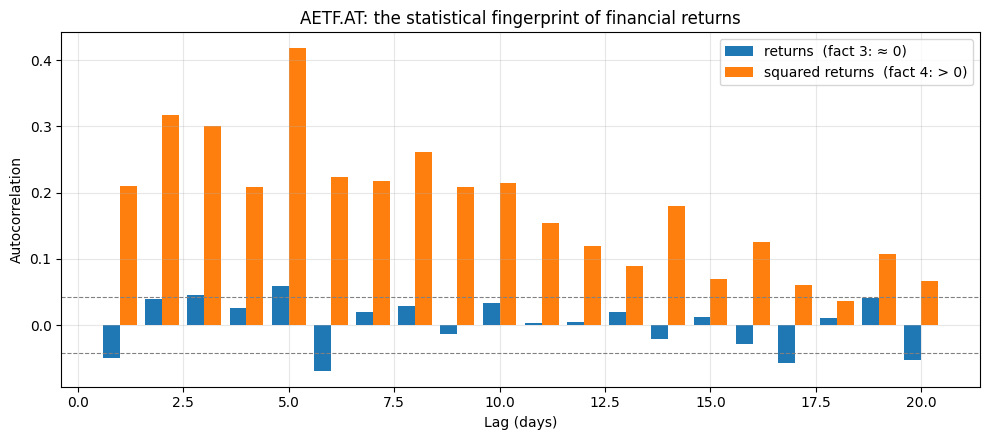

In [151]:
# ============================================================
# Cell 9 — Verifying stylized facts 3 & 4: the ACF fingerprint
# ============================================================
# Autocorrelation at lag k: correlation between r_t and r_{t-k}.
# pandas' .autocorr(lag=k) computes it directly.

LAGS = range(1, 21)   # look back up to 20 trading days (~1 month)
asset = "AETF.AT"         # 

r = log_ret[asset]
acf_r  = [r.autocorr(lag=k) for k in LAGS]         # returns themselves
acf_r2 = [(r**2).autocorr(lag=k) for k in LAGS]    # SQUARED returns (magnitude proxy)

fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.4
ax.bar([k - w/2 for k in LAGS], acf_r,  width=w, label="returns  (fact 3: ≈ 0)")
ax.bar([k + w/2 for k in LAGS], acf_r2, width=w, label="squared returns  (fact 4: > 0)")
# Approximate 95% significance band for white noise: ±1.96/√n
band = 1.96 / np.sqrt(len(r))
ax.axhline(band, color="gray", ls="--", lw=0.8); ax.axhline(-band, color="gray", ls="--", lw=0.8)
ax.set_title(f"{asset}: the statistical fingerprint of financial returns")
ax.set_xlabel("Lag (days)"); ax.set_ylabel("Autocorrelation")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# READ THE CHART: blue bars hug zero (direction unpredictable); orange bars
# stand clearly outside the gray band (magnitude IS predictable).
# You have just reproduced, on your own data, one of the most robust
# findings in all of empirical finance.


---
# 8 · What you just did — and who will do it next

Step back and list your workflow today:

> download data → load & standardize → align calendars → compute returns → chart → summarize → verify against theory

In a few weeks, this exact pipeline becomes the **toolbox of your Data & Analyst Agents**: each function you wrote (`load_price_file`, `generate_gbm`, `summarize`) is precisely the kind of *tool* an AI agent calls. The agent will run this analysis in seconds on any asset you name.

But here is the point of doing it by hand first: when your agent one day reports *"Bitcoin's annualized volatility is 12%"*, you will feel in your bones that this is wrong — because today you saw it is several times higher. **The orchestrator's power is not writing code; it is knowing what correct looks like.** Today you calibrated that instinct.

---

# 9 · Optional extension A — a taste of SQL (zero installation)

Databases are where institutional data lives; SQL is how you ask them questions. You do **not** need to install PostgreSQL/pgAdmin for this course — Python ships with **SQLite**, a complete SQL engine, built in. (If you want the industrial experience, PostgreSQL + pgAdmin is a great optional side quest.)


In [152]:
#============================================================
# Cell 10 (OPTIONAL) — SQL in 60 Seconds with SQLite
# ============================================================

import sqlite3

# Create a SQLite database file
conn = sqlite3.connect("week1.db")

# Push our aligned price table into the database
prices.reset_index().rename(columns={"index": "date"}).to_sql(
    "daily_prices",
    conn,
    if_exists="replace",
    index=False
)

# Now ask questions in SQL.
# Here we compare ETH with AETF.AT and IEGE.AS.
query = """
SELECT
    date,
    "ETH-USD",
    "AETF.AT",
    "IEGE.AS",
    "ETH-USD" / "AETF.AT" AS eth_per_aetf,
    "ETH-USD" / "IEGE.AS" AS eth_per_iege
FROM daily_prices
ORDER BY date DESC
LIMIT 5;
"""

print(pd.read_sql(query, conn))

# Close the database connection
conn.close()

# That's the core loop of institutional data work: Python for analysis,
# SQL for storage and retrieval. Week 2 goes deeper for those interested.


                  date    ETH-USD  AETF.AT  IEGE.AS  eth_per_aetf  eth_per_iege
0  2026-09-10 00:00:00 2,461.6899  69.4200  98.7000       35.4608       24.9411
1  2026-09-08 00:00:00 2,484.9414  69.8200  98.7700       35.5907       25.1589
2  2026-09-07 00:00:00 2,490.9580  69.7000  98.7500       35.7383       25.2249
3  2026-09-04 00:00:00 2,456.0781  69.5300  98.7600       35.3240       24.8692
4  2026-09-03 00:00:00 2,508.0208  69.2500  98.7500       36.2169       25.3977


---
# 10 · Optional extension B — GitHub as your public portfolio

Also optional, also recommended: create a free [GitHub](https://github.com) account, create a repository (e.g. `fintech-ai-portfolio`), and upload this notebook via *Add file → Upload files* — no command line needed. By week 11 that repository will contain your entire product build, and **a link to it belongs on your CV**. Recruiters in quant finance and FinTech routinely check GitHub before they check references.

---

# ✅ Week 1 deliverable checklist

Submit by email before the deadline:

- This notebook, executed top to bottom with **real downloaded data** for at least one asset (`Kernel → Restart & Run All` before saving — a professional habit that proves reproducibility).
- Below this cell, add a markdown cell with **3–5 sentences of your own observations**: which stylized facts did *your* data confirm? What surprised you?
- *(Optional)* your SQLite query output and/or your GitHub repo link.

# 🔭 Next week

**Week 2 — Data Wrangling & Hygiene:** real data is dirty — duplicates, gaps, timezones, impossible prices. You will build the cleaning discipline that later becomes your *Data Quality Agent's* rulebook. Bring this week's downloaded files; we operate on them.
